Reducing dimensions of the distance matrix with PCA to prepare for clustering.

In [12]:
!pip install scikit-learn #Installing sklearn
!pip install matplotlib #Installing matplotlib


from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np


In [13]:
df_distance_matrix = pd.read_csv('antibodies_distance_matrix.csv', index_col=0) 

pca = PCA(n_components=3) #Saves amount of components to variable "pca"
principal_components_antibody = pca.fit_transform(df_distance_matrix)  #Saves matrix transformed through PCA 

print(pca.explained_variance_ratio_) #Prints the explained variance of each Principal Component

pd.DataFrame(principal_components_antibody, index=df_distance_matrix.index, columns=['PC1', 'PC2', 'PC3']).to_csv('antibodies_principal_components.csv')



[0.93306234 0.04212088 0.00831613]


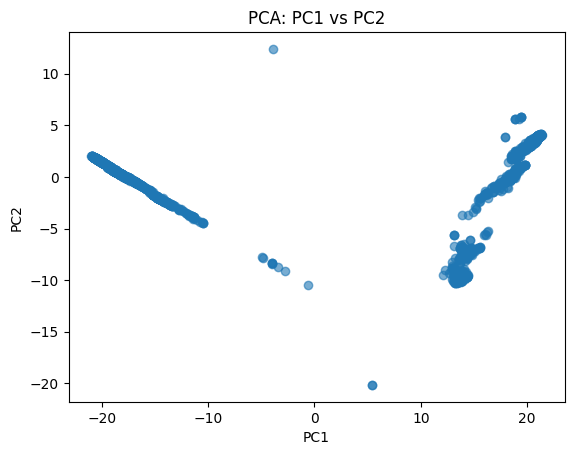

In [14]:
plt.scatter(principal_components_antibody[:, 0], principal_components_antibody[:, 1], alpha=0.6) #Generating Graphical Representation of PCA 1 and 2
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.show()

In [15]:
#Same code as above, only now for the CDR3 PCA

df_distance_matrix = pd.read_csv('CDR3_distance_matrix.csv', index_col=0) #Reading the distance matrix into a Dataframe

pca = PCA(n_components=3) #Saves amount of components to variable "pca"
principal_components_CDR3 = pca.fit_transform(df_distance_matrix)  #Saves matrix transformed through PCA 

print(pca.explained_variance_ratio_) #Prints the explained variance of each Principal Component

pd.DataFrame(principal_components_CDR3, index=df_distance_matrix.index, columns=['PC1', 'PC2', 'PC3']).to_csv('CDR3_principal_components.csv')

[0.31075749 0.14600451 0.08177833]


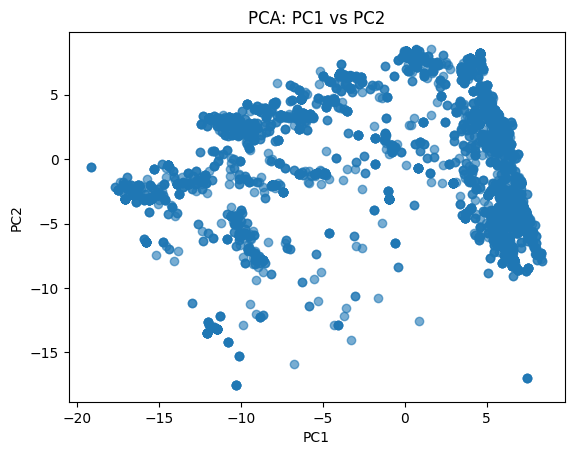

In [16]:
#CDR3 PCA visulization

plt.scatter(principal_components_CDR3[:, 0], principal_components_CDR3[:, 1], alpha=0.6) #Generating Graphical Representation of PCA 1 and 2
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA: PC1 vs PC2')
plt.show()


Now after completing the PCA we will use the reduced Data to identify clusters using k-means clustering.

In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df_distance_matrix = pd.read_csv('antibodies_distance_matrix.csv', index_col=0)

sequence_ids = df_distance_matrix.index.tolist()

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(principal_components_antibody)
labels = kmeans.labels_

# Creating dataframe
df_clusters_antibody = pd.DataFrame(principal_components_antibody, columns=['PC1', 'PC2', 'PC3'], index=sequence_ids)
df_clusters_antibody['Cluster'] = labels

print(df_clusters_antibody.head())

df_clusters_antibody.to_csv('antibodies_pca_clusters.csv')



                                       PC1       PC2       PC3  Cluster
7ZOZ_2|H|antigen_species=homo   -17.774919 -0.038323 -2.257157        1
7ZOZ_3|L|antigen_species=homo    19.201329  2.426000 -0.645406        0
6PE8_1|A,H|antigen_species=homo -20.560191  1.775447  2.087733        1
6PE8_2|B,L|antigen_species=homo  19.858486  2.790911 -0.329514        0
8IVX_2|H|antigen_species=homo   -14.320396 -2.125524 -1.785295        1


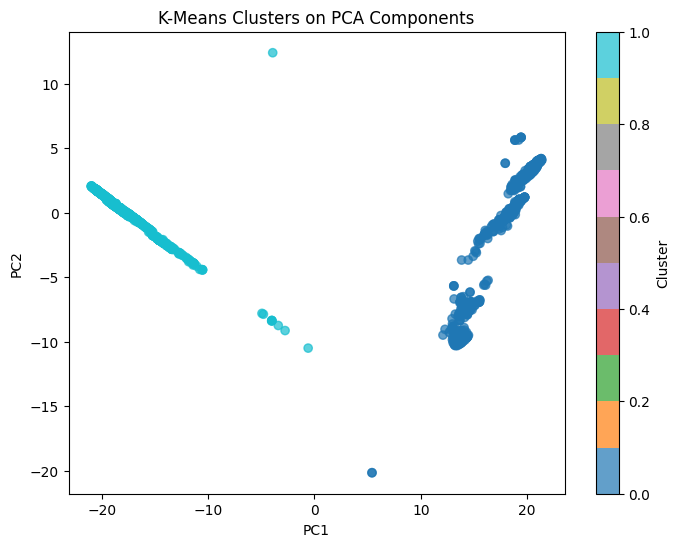

In [ ]:
import matplotlib.pyplot as plt #Visualizing the Clusters

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_clusters_antibody['PC1'], df_clusters_antibody['PC2'], c=df_clusters_antibody['Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA Components')
plt.colorbar(scatter, label='Cluster')
plt.show()


In [ ]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

df_distance_matrix = pd.read_csv('CDR3_distance_matrix.csv', index_col=0)

sequence_ids = df_distance_matrix.index.tolist()

k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(principal_components_CDR3)
labels = kmeans.labels_

# Creating dataframe
df_clusters_CDR3 = pd.DataFrame(principal_components_CDR3, columns=['PC1', 'PC2', 'PC3'], index=sequence_ids)
df_clusters_CDR3['Cluster'] = labels

print(df_clusters_CDR3.head())

df_clusters_CDR3.to_csv('CDR3_pca_clusters.csv')

                         PC1       PC2       PC3  Cluster
8WU1|H|Homo         3.838919  2.287458 -1.100018        0
8WU1|L|Homo       -12.610780 -5.037396 -3.443073        1
3LQA|H|Homo         5.949256  2.062381 -1.108142        0
3LQA|L|Homo         4.589084  7.711065 -3.941725        0
4KXZ|H,J,N,Q|Homo   5.651870 -4.722849  2.296878        0


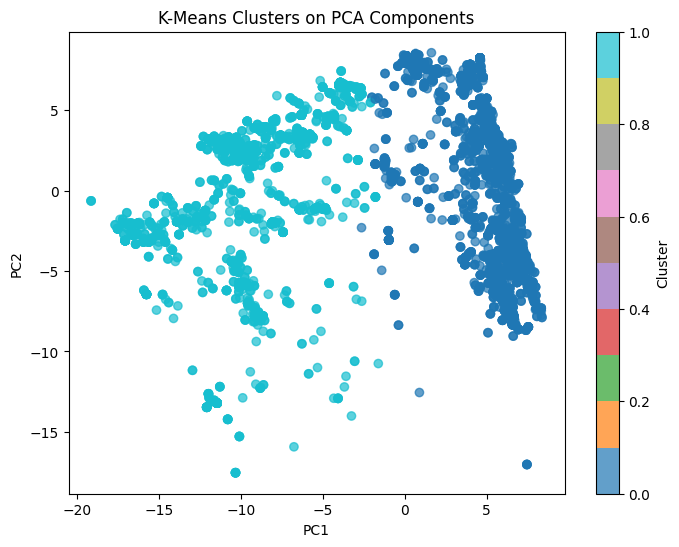

In [ ]:
import matplotlib.pyplot as plt #Visualizing the Clusters

plt.figure(figsize=(8,6))
scatter = plt.scatter(df_clusters_CDR3['PC1'], df_clusters_CDR3['PC2'], c=df_clusters_CDR3['Cluster'], cmap='tab10', alpha=0.7)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('K-Means Clusters on PCA Components')
plt.colorbar(scatter, label='Cluster')
plt.show()